# Configuration

In [1]:
import os 
import pickle 

if True ^ os.getcwd().endswith('hte-and-targeting'):
    os.chdir('..')

from typing import Union, List, Iterable

In [2]:
import random
import pandas as pd 
import numpy as np

from tqdm import tqdm

In [3]:
from statsmodels.regression.linear_model import OLS

In [4]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# visualization params
# label size
tick_label_size = 12
legend_label_size = 12
axis_label_size = 14
title_size = 18
# font
plt.rcParams['font.family'] = 'serif'

In [5]:
from core.variables import *
from core.m_out_of_n_bootstrap import choose_best_m
from core.dgp import SingleSegment
import core.binary_treatments_single_segment as btss

# DGP

In [6]:
dgp = SingleSegment(
    **{'te': 0.6, 'noise_std': 2, 'treatment_space': np.array([0, 1])}
)
treatment_arr, outcome_arr = dgp.sample(sample_size=1000, seed=0)

# Demand Model

In [7]:
emp_te = btss.difference_in_mean(treatments=treatment_arr, outcomes=outcome_arr)

print(f'True Treatment Effect: {dgp.te:.2f}')
print(f'Estimated Treatment Effect: {emp_te:.2f}')

True Treatment Effect: 0.60
Estimated Treatment Effect: 0.87


# Optimization

$$
\begin{aligned}
V(\tau) & = \max\{p\tau - c, 0\} \\
& = \max\{p\tau, c\} - c \\ 
& = p \max\{\tau, c / p\} - c
\end{aligned}
$$

Optimal targeting policy $\pi$: 
$$
\pi(P, p, c) = \begin{cases}
1, \quad \text{if } \theta(P) \geq c / p \\ 
0, \quad \text{o.w.}
\end{cases}
$$

In [8]:
plugin_decision, plugin_targ_val_est = btss.optimize(
    te=emp_te, price=1, cost=0.5
)
plugin_targ_val = btss.objective_func(
    targ_decision=plugin_decision, te=dgp.te, price=1, cost=0.5
)

print(f'Plugin Decision: {plugin_decision}')
print(f'Estimated Targeting Value: {plugin_targ_val_est:.2f}')
print(f'True Targeting Value: {plugin_targ_val:.2f}')

Plugin Decision: True
Estimated Targeting Value: 0.37
True Targeting Value: 0.10


## Shape of Value Function

In [9]:
def plot_value_function(
    price: float, cost: float, tau_lb: float, tau_ub: float, 
): 
    tau_arr = np.linspace(tau_lb, tau_ub, 1000)
    V_arr = np.maximum(tau_arr * price - cost, 0)

    fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

    # plot valuation function
    ax.plot(tau_arr, V_arr, color='black')

    # mark discontinuous point
    ax.plot(cost / price, 0, 'r*', markersize=20, label='Nondifferentiable Point')

    # plot attributes
    ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
    ax.set_title('Optimal Targeting Value Function', fontsize=title_size)
    ax.set_xlabel('Treatment Effect', fontsize=axis_label_size)
    ax.set_ylabel('Optimal Targeting Value', fontsize=axis_label_size)
    ax.legend(loc='best', fontsize=legend_label_size)
    ax.grid()

    plt.tight_layout()
    plt.show()

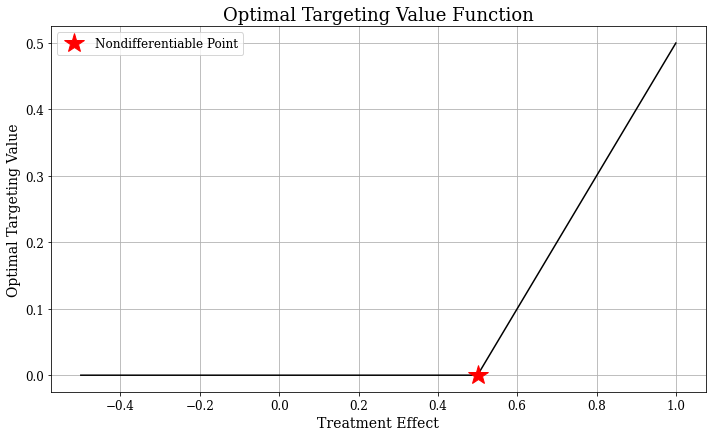

In [10]:
plot_value_function(price=1, cost=0.5, tau_lb=-0.5, tau_ub=1)

In [11]:
# clean memory
del dgp, treatment_arr, outcome_arr, emp_te, plugin_decision, plugin_targ_val_est, plugin_targ_val

# Winner's Curse

$$
\begin{aligned}
WC(\hat{\tau}) & = \max\{p\hat{\tau} - c, 0\} - (p\tau - c) \mathbb{I}\{\hat{\tau} \geq c / p\} \\
& = p (\hat{\tau} - \tau) \mathbb{I}\{\hat{\tau} \geq c / p\} \\ 
& = \begin{cases}
p (\hat{\tau} - \tau), \quad & \text{if } \hat{\tau} > c / p \\ 
0, \quad & \text{if } \hat{\tau} = c / p \\ 
0, \quad & \text{if } \hat{\tau} < c / p \\ 
\end{cases}
\end{aligned}
$$

Expected winner's curse: 
$$
WC = \mathrm{E}\left[ p (\hat{\tau} - \tau) \mathbb{I}\{\hat{\tau} \geq c / p\}\right]
$$

In [66]:
operations_params = {'price': 1, 'cost': 0.5}

dgp_params = {'te': 0.6, 'noise_std': 2, 'treatment_space': np.array([0, 1])}

data_params = {'sample_size': 200}

experiment_params = {'n_experiments': 10000, 'conditional_on_treated': False, 'stats': 'mean'} 

# empirical distribution of winner's curse
estimators_dict = {}

result_records = btss.repeated_experiments(
    operations_params=operations_params,
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict
)

plugin_decision_arr = np.array([record['plugin_decision'] for record in result_records])
emp_wc_arr = np.array([record[f'plugin_wc'] for record in result_records])
emp_wc_pct_arr = 100 * np.array([record[f'plugin_wc'] / record['clairvoyant_val'] for record in result_records])
emp_cond_wc_arr = emp_wc_arr[plugin_decision_arr == 1]
emp_cond_wc_pct_arr = emp_wc_pct_arr[plugin_decision_arr == 1]

avg_wc = np.mean(emp_wc_arr)
avg_wc_pct = np.mean(emp_wc_pct_arr)
se_wc = np.std(emp_wc_arr) / np.sqrt(data_params['sample_size'])
se_wc_pct = np.std(emp_wc_pct_arr) / np.sqrt(data_params['sample_size'])

avg_wc_pct_on_treated = np.mean(emp_cond_wc_pct_arr)
se_wc_pct_on_treated = np.std(emp_cond_wc_pct_arr) / np.sqrt(data_params['sample_size'])

print(f'Average Empirical Winner\'s Curse: {avg_wc:.2f} ({se_wc:.2f})')
print(f'Average Empirical Winner\'s Curse Percentage: {avg_wc_pct:.2f}% ({se_wc_pct:.2f}%)')
print(f'Average Empirical Winner\'s Curse Percentage on Treated: {avg_wc_pct_on_treated:.2f}% ({se_wc_pct_on_treated:.2f}%)')

Average Empirical Winner's Curse: 0.11 (0.01)
Average Empirical Winner's Curse Percentage: 109.51% (12.33%)
Average Empirical Winner's Curse Percentage on Treated: 169.58% (13.58%)


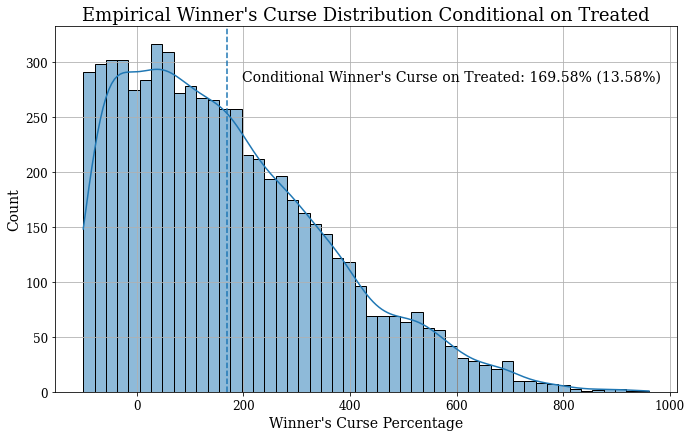

In [67]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(emp_cond_wc_pct_arr, bins=50, color='C0', ax=ax, kde=True, stat='count')
ax.axvline(
    x=avg_wc_pct_on_treated, color='C0', linestyle='--'
)
ax.annotate(
    f"Conditional Winner's Curse on Treated: {avg_wc_pct_on_treated:.2f}% ({se_wc_pct_on_treated:.2f}%)", 
    xy=(0.3, 0.85), xycoords='axes fraction', fontsize=axis_label_size
)

ax.set_title('Empirical Winner\'s Curse Distribution Conditional on Treated', fontsize=title_size)
ax.set_xlabel('Winner\'s Curse Percentage', fontsize=axis_label_size)
ax.set_ylabel('Count', fontsize=axis_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()

plt.tight_layout()
plt.show()

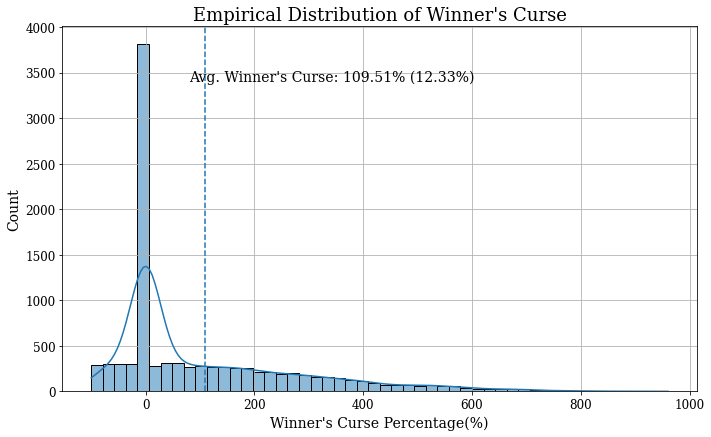

In [68]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(emp_wc_pct_arr, bins=50, kde=True, stat='count', ax=ax, color='C0')
ax.axvline(emp_wc_pct_arr.mean(), color='C0', linestyle='--')
ax.annotate(
    f"Avg. Winner's Curse: {avg_wc_pct:.2f}% ({se_wc_pct:.2f}%)", 
    xy=(0.2, 0.85), xycoords='axes fraction', fontsize=axis_label_size
)
ax.set_title("Empirical Distribution of Winner's Curse", fontsize=title_size)

ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.set_xlabel("Winner's Curse Percentage(%)", fontsize=axis_label_size)
ax.set_ylabel('Count', fontsize=axis_label_size)
ax.grid()

plt.tight_layout()
# plt.savefig('figures/case1-winners-curse-dstn.png')
plt.show()

# Estimating winner's curse

## Standard Bootstrap

In [69]:
dgp = SingleSegment(**dgp_params)
treatment_arr, outcome_arr = dgp.sample(**data_params, seed=0)

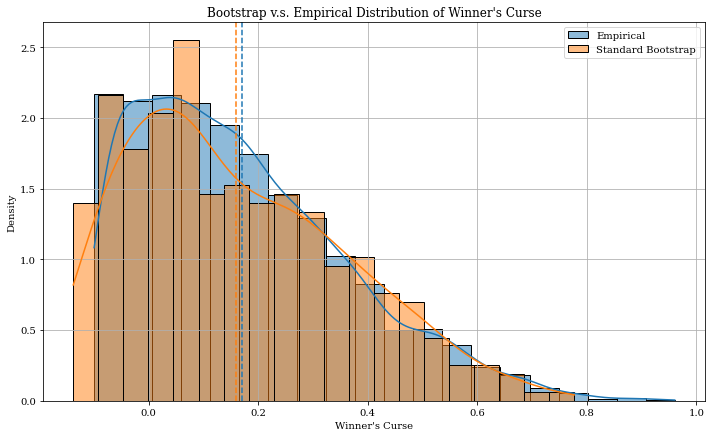

In [70]:
# generate bootstrap distribution
boot_wc_dstn_arr = btss.get_wc_boot_dstn(
    treatments=treatment_arr, outcomes=outcome_arr,
    **operations_params, n_bootstraps=500, conditional_on_treated=True, 
)

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(emp_cond_wc_arr, bins=20, kde=True, stat='density', ax=ax, color='C0', label='Empirical')
ax.axvline(emp_cond_wc_arr.mean(), color='C0', linestyle='--')

sns.histplot(boot_wc_dstn_arr, bins=20, kde=True, stat='density', ax=ax, color='C1', label='Standard Bootstrap')
ax.axvline(boot_wc_dstn_arr.mean(), color='C1', linestyle='--')

ax.set_title("Bootstrap v.s. Empirical Distribution of Winner's Curse")
ax.set_xlabel("Winner's Curse")
ax.set_ylabel('Density')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

## m-out-of-n Bootstrap

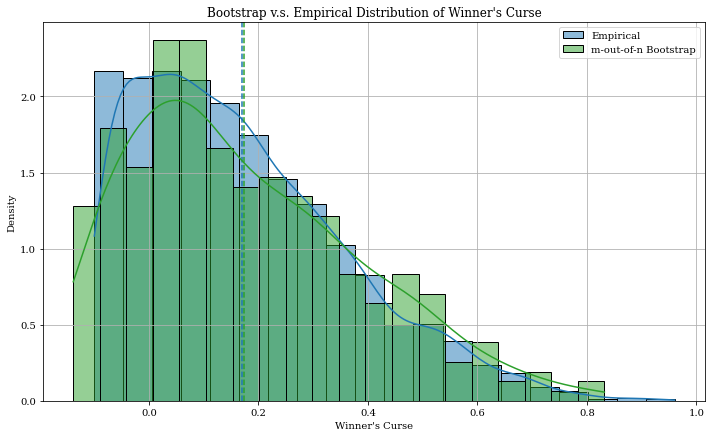

In [71]:
# generate bootstrap distribution
mn_boot_wc_dstn_arr = btss.get_wc_m_out_of_n_boot_dstn(
    treatments=treatment_arr, outcomes=outcome_arr, **operations_params, 
    n_bootstraps=500, power=0.95, conditional_on_treated=True
)
# mn_boot_wc_dstn_arr /= clairvoyant_opt_obj

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(emp_cond_wc_arr, bins=20, kde=True, stat='density', ax=ax, color='C0', label='Empirical')
ax.axvline(emp_cond_wc_arr.mean(), color='C0', linestyle='--')

sns.histplot(mn_boot_wc_dstn_arr, bins=20, kde=True, stat='density', ax=ax, color='C2', label='m-out-of-n Bootstrap')
ax.axvline(mn_boot_wc_dstn_arr.mean(), color='C2', linestyle='--')

ax.set_title("Bootstrap v.s. Empirical Distribution of Winner's Curse")
ax.set_xlabel("Winner's Curse")
ax.set_ylabel('Density')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

## Numerical Bootstrap

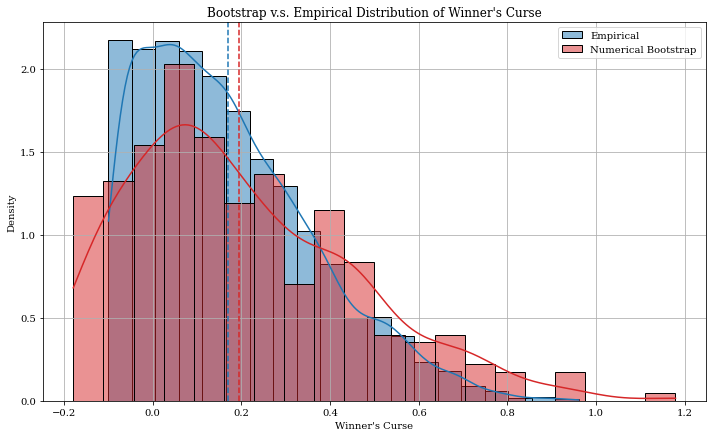

In [72]:
# generate bootstrap distribution
num_boot_wc_dstn_arr = btss.get_wc_num_boot_dstn(
    treatments=treatment_arr, outcomes=outcome_arr, **operations_params, 
    n_bootstraps=500, power=-0.45, conditional_on_treated=True
)
# num_boot_wc_dstn_arr /= clairvoyant_opt_obj

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(emp_cond_wc_arr, bins=20, kde=True, stat='density', ax=ax, color='C0', label='Empirical')
ax.axvline(emp_cond_wc_arr.mean(), color='C0', linestyle='--')

sns.histplot(num_boot_wc_dstn_arr, bins=20, kde=True, stat='density', ax=ax, color='C3', label='Numerical Bootstrap')
ax.axvline(num_boot_wc_dstn_arr.mean(), color='C3', linestyle='--')

ax.set_title("Bootstrap v.s. Empirical Distribution of Winner's Curse")
ax.set_xlabel("Winner's Curse")
ax.set_ylabel('Density')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

# Bias Correction

## Correcting the Average Winner's Curse

In [54]:
operations_params = {'price': 1, 'cost': 0.5}

dgp_params = {'te': 0.6, 'noise_std': 2, 'treatment_space': np.array([0, 1])}

data_params = {'sample_size': 200}

experiment_params = {'n_experiments': 5000, 'conditional_on_treated': False, 'stats': 'mean'}

estimators_dict = {
    'stand_bootstrap': {
        'estimator': btss.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'standard',
        }
    }, 
    'mn_bootstrap': {
        'estimator': btss.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'm_out_of_n', 
            'power': 0.95,
        }
    }, 
    'num_bootstrap': {
        'estimator': btss.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'numerical', 
            'power': - 0.45,
        }
    }
}

In [55]:
result_records = btss.repeated_experiments(
    operations_params=operations_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, n_jobs=-1
)

Running 5000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    4.3s
[Parallel(n_jobs=-1)]: Done 840 tasks      | elapsed:    9.6s
[Parallel(n_jobs=-1)]: Done 1540 tasks      | elapsed:   16.7s
[Parallel(n_jobs=-1)]: Done 2440 tasks      | elapsed:   26.2s
[Parallel(n_jobs=-1)]: Done 3540 tasks      | elapsed:   37.6s
[Parallel(n_jobs=-1)]: Done 4840 tasks      | elapsed:   50.7s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:   52.6s finished


In [56]:
wc_pct_df = pd.DataFrame.from_records({
    f'{name}': 100 * np.array([record[f'{name}_wc']/record['clairvoyant_val'] for record in result_records])
    for name in ['plugin'] + list(estimators_dict.keys())
})

print(wc_pct_df.describe())
print()

for col in wc_pct_df.columns:
    avg_wc_pct = wc_pct_df[col].mean()
    se_wc_pct = wc_pct_df[col].std() / np.sqrt(data_params['sample_size'])
    median_wc_pct = np.median(wc_pct_df[col])

    print(f'{col}: {avg_wc_pct:.2f}% ({se_wc_pct:.2f}%)')

       mn_bootstrap  num_bootstrap       plugin  stand_bootstrap
count   5000.000000    5000.000000  5000.000000      5000.000000
mean      15.671427       9.899526   109.220540        33.011101
std      203.728463     210.987968   174.033381       202.046433
min     -247.172215    -267.440712   -99.586906      -225.365934
25%     -121.735741    -136.478733    -0.000000      -104.790927
50%      -71.054988     -75.897551     4.626227       -52.781882
75%      112.652254     111.655621   194.461824       132.976754
max      951.592750     959.797586   960.485807       949.336312

mn_bootstrap: 15.67% (14.41%)
num_bootstrap: 9.90% (14.92%)
plugin: 109.22% (12.31%)
stand_bootstrap: 33.01% (14.29%)


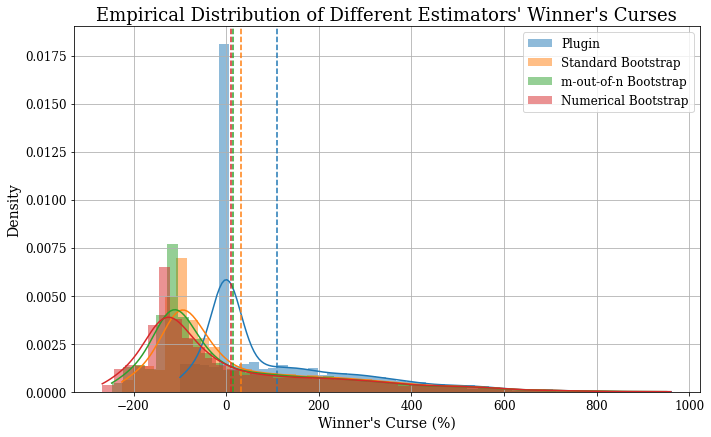

In [57]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# historgram of plugin estimator's winner's curse
sns.histplot(wc_pct_df['plugin'], bins=50, kde=True, stat='density', ax=ax, color='C0', edgecolor=None, label='Plugin')
ax.axvline(wc_pct_df['plugin'].mean(), color='C0', linestyle='--')

# historgram of standard bootstrap estimator's winner's curse
sns.histplot(wc_pct_df['stand_bootstrap'], bins=50, kde=True, stat='density', ax=ax, color='C1', edgecolor=None, label='Standard Bootstrap')
ax.axvline(wc_pct_df['stand_bootstrap'].mean(), color='C1', linestyle='--')

# historgram of m-out-of-n bootstrap estimator's winner's curse
sns.histplot(wc_pct_df['mn_bootstrap'], bins=50, kde=True, stat='density', ax=ax, color='C2', edgecolor=None, label='m-out-of-n Bootstrap')
ax.axvline(wc_pct_df['mn_bootstrap'].mean(), color='C2', linestyle='--')

# historgram of numerical bootstrap estimator's winner's curse
sns.histplot(wc_pct_df['num_bootstrap'], bins=50, kde=True, stat='density', ax=ax, color='C3', edgecolor=None, label='Numerical Bootstrap')
ax.axvline(wc_pct_df['num_bootstrap'].mean(), color='C3', linestyle='--')

ax.set_title("Empirical Distribution of Different Estimators' Winner's Curses", fontsize=title_size)
ax.set_xlabel("Winner's Curse (%)", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.legend(loc='best', fontsize=legend_label_size)
ax.grid()

plt.tight_layout()
plt.show()

## Correcting the Avg. Winner's Curse Conditional on Treated

In [73]:
operations_params = {'price': 1, 'cost': 0.5}

dgp_params = {'te': 0.6, 'noise_std': 2, 'treatment_space': np.array([0, 1])}

data_params = {'sample_size': 200}

experiment_params = {'n_experiments': 5000, 'conditional_on_treated': True, 'stats': 'mean'}

estimators_dict = {
    'stand_bootstrap': {
        'estimator': btss.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'standard',
        }
    }, 
    'mn_bootstrap': {
        'estimator': btss.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'm_out_of_n', 
            'power': 0.90,
        }
    }, 
    'num_bootstrap': {
        'estimator': btss.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'numerical', 
            'power': - 0.40,
        }
    }
}

In [74]:
result_records = btss.repeated_experiments(
    operations_params=operations_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, n_jobs=-1
)

Running 5000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 560 tasks      | elapsed:    4.0s
[Parallel(n_jobs=-1)]: Done 2560 tasks      | elapsed:   17.1s
[Parallel(n_jobs=-1)]: Done 4981 out of 5000 | elapsed:   32.0s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:   32.0s finished


In [75]:
wc_pct_df = pd.DataFrame.from_records({
    f'{name}': 100 * np.array([record[f'{name}_wc']/record['clairvoyant_val'] for record in result_records])
    for name in ['plugin'] + list(estimators_dict.keys())
})

print(wc_pct_df.describe())
print()

for col in wc_pct_df.columns:
    avg_wc_pct = wc_pct_df[col].mean()
    se_wc_pct = wc_pct_df[col].std() / np.sqrt(data_params['sample_size'])

    print(f'{col}: {avg_wc_pct:.2f}% ({se_wc_pct:.2f}%)')

       mn_bootstrap  num_bootstrap       plugin  stand_bootstrap
count   3223.000000    3223.000000  3223.000000      3223.000000
mean       8.265552      -5.664419   169.439248        66.423721
std      267.639499     297.986542   191.794914       253.579662
min     -451.134148    -531.978135   -99.586906      -345.837524
25%     -207.961701    -248.149267    14.980095      -140.977460
50%      -29.945265     -33.966165   136.241182        36.032628
75%      189.684958     209.110410   287.951909       241.497587
max      972.548882     941.272006   960.485807       949.336312

mn_bootstrap: 8.27% (18.92%)
num_bootstrap: -5.66% (21.07%)
plugin: 169.44% (13.56%)
stand_bootstrap: 66.42% (17.93%)


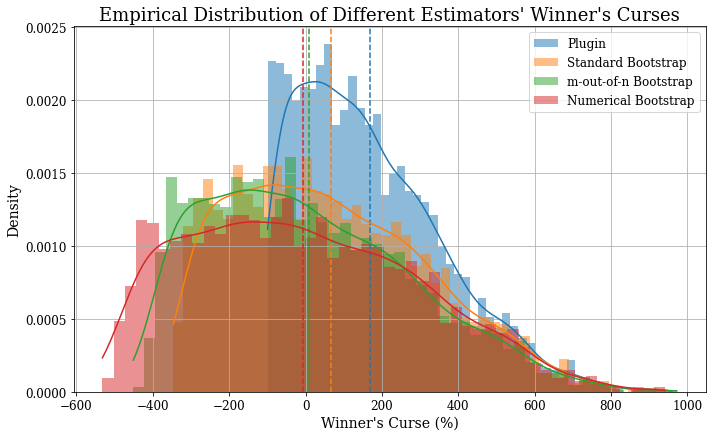

In [76]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# historgram of plugin estimator's winner's curse
sns.histplot(wc_pct_df['plugin'], bins=50, kde=True, stat='density', ax=ax, color='C0', edgecolor=None, label='Plugin')
ax.axvline(wc_pct_df['plugin'].mean(), color='C0', linestyle='--')

# historgram of standard bootstrap estimator's winner's curse
sns.histplot(wc_pct_df['stand_bootstrap'], bins=50, kde=True, stat='density', ax=ax, color='C1', edgecolor=None, label='Standard Bootstrap')
ax.axvline(wc_pct_df['stand_bootstrap'].mean(), color='C1', linestyle='--')

# historgram of m-out-of-n bootstrap estimator's winner's curse
sns.histplot(wc_pct_df['mn_bootstrap'], bins=50, kde=True, stat='density', ax=ax, color='C2', edgecolor=None, label='m-out-of-n Bootstrap')
ax.axvline(wc_pct_df['mn_bootstrap'].mean(), color='C2', linestyle='--')

# historgram of numerical bootstrap estimator's winner's curse
sns.histplot(wc_pct_df['num_bootstrap'], bins=50, kde=True, stat='density', ax=ax, color='C3', edgecolor=None, label='Numerical Bootstrap')
ax.axvline(wc_pct_df['num_bootstrap'].mean(), color='C3', linestyle='--')

ax.set_title("Empirical Distribution of Different Estimators' Winner's Curses", fontsize=title_size)
ax.set_xlabel("Winner's Curse (%)", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.legend(loc='best', fontsize=legend_label_size)
ax.grid()

plt.tight_layout()
plt.show()

## Correctign the Median of Winner's Curse Conditional on Treated

In [89]:
operations_params = {'price': 1, 'cost': 0.5}

dgp_params = {'te': 0.6, 'noise_std': 2, 'treatment_space': np.array([0, 1])}

data_params = {'sample_size': 200}

experiment_params = {'n_experiments': 5000, 'conditional_on_treated': True, 'stats': 'median'}

estimators_dict = {
    'stand_bootstrap': {
        'estimator': btss.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'standard',
        }
    }, 
    'mn_bootstrap': {
        'estimator': btss.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'm_out_of_n', 
            'power': 0.9,
        }
    }, 
    'num_bootstrap': {
        'estimator': btss.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'numerical', 
            'power': - 0.4,
        }
    }
}

In [90]:
result_records = btss.repeated_experiments(
    operations_params=operations_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, n_jobs=-1
)

Running 5000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.4s


In [87]:
wc_pct_df = pd.DataFrame.from_records({
    f'{name}': 100 * np.array([record[f'{name}_wc']/record['clairvoyant_val'] for record in result_records])
    for name in ['plugin'] + list(estimators_dict.keys())
})

print(wc_pct_df.describe())
print()

for col in wc_pct_df.columns:
    # avg_wc_pct = wc_pct_df[col].mean()
    median_wc_pct = np.median(wc_pct_df[col])
    se_wc_pct = wc_pct_df[col].std() / np.sqrt(data_params['sample_size'])

    print(f'{col} median: {median_wc_pct:.2f}% ({se_wc_pct:.2f}%)')

       mn_bootstrap  num_bootstrap       plugin  stand_bootstrap
count   3223.000000    3223.000000  3223.000000      3223.000000
mean      69.361816      66.694905   169.439248        90.425512
std      251.531510     260.786514   191.794914       244.178803
min     -352.097610    -376.502435   -99.586906      -309.881929
25%     -134.133595    -143.980420    14.980095      -108.727771
50%       38.159886      40.071380   136.241182        62.378498
75%      244.722189     250.401891   287.951909       259.733105
max      950.587195     957.654500   960.485807       953.542654

mn_bootstrap median: 38.16% (17.79%)
num_bootstrap median: 40.07% (18.44%)
plugin median: 136.24% (13.56%)
stand_bootstrap median: 62.38% (17.27%)


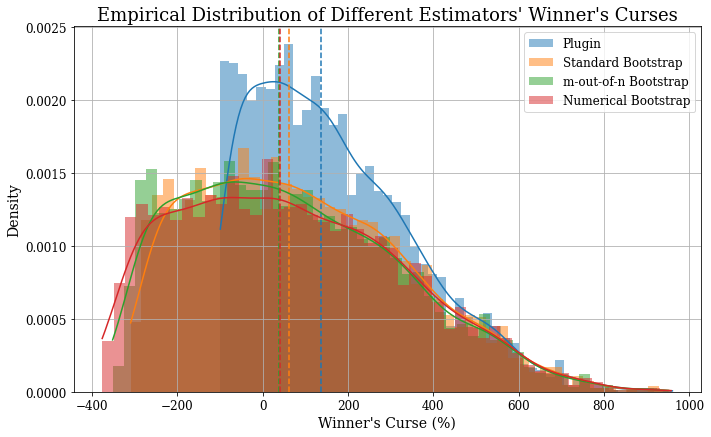

In [88]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# historgram of plugin estimator's winner's curse
sns.histplot(wc_pct_df['plugin'], bins=50, kde=True, stat='density', ax=ax, color='C0', edgecolor=None, label='Plugin')
ax.axvline(wc_pct_df['plugin'].median(), color='C0', linestyle='--')

# historgram of standard bootstrap estimator's winner's curse
sns.histplot(wc_pct_df['stand_bootstrap'], bins=50, kde=True, stat='density', ax=ax, color='C1', edgecolor=None, label='Standard Bootstrap')
ax.axvline(wc_pct_df['stand_bootstrap'].median(), color='C1', linestyle='--')

# historgram of m-out-of-n bootstrap estimator's winner's curse
sns.histplot(wc_pct_df['mn_bootstrap'], bins=50, kde=True, stat='density', ax=ax, color='C2', edgecolor=None, label='m-out-of-n Bootstrap')
ax.axvline(wc_pct_df['mn_bootstrap'].median(), color='C2', linestyle='--')

# historgram of numerical bootstrap estimator's winner's curse
sns.histplot(wc_pct_df['num_bootstrap'], bins=50, kde=True, stat='density', ax=ax, color='C3', edgecolor=None, label='Numerical Bootstrap')
ax.axvline(wc_pct_df['num_bootstrap'].median(), color='C3', linestyle='--')

ax.set_title("Empirical Distribution of Different Estimators' Winner's Curses", fontsize=title_size)
ax.set_xlabel("Winner's Curse (%)", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.legend(loc='best', fontsize=legend_label_size)
ax.grid()

plt.tight_layout()
plt.show()

# Sensitivity Analysis

## Hyperparameter

### m-out-of-n

In [60]:
targeting_params = {'price': 1, 'cost': 0.5}

dgp_params = {'te': np.nan, 'noise_std': 5, 'treatment_space': np.array([0, 1])}

data_params = {'sample_size': 200}

experiment_params = {'n_experiments': 1000}

estimators_dict = {
    'stand_bootstrap': {
        'estimator': btss.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard'}
    }, 
    'mn_bootstrap': {
        'estimator': btss.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'm_out_of_n', 
            'power': np.nan
        }
    }, 
}

In [ ]:
te_list = [-0.2, 0, 0.2, 0.4, 0.5, 0.6, 0.8, 1]
power_list = [0.88, 0.90, 0.92, 0.95, 0.97]
result_dict = {(te, power): None for te in te_list for power in power_list}

for te in te_list:
    dgp_params['te'] = te
    for power in power_list: 
        print(f'Te = {te}, Power = {power}')
        estimators_dict['mn_bootstrap']['params']['power'] = power
        
        result_record = btss.repeated_experiments(
            operations_params=operations_params, 
            dgp_params=dgp_params, 
            data_params=data_params, 
            experiment_params=experiment_params, 
            estimators_dict=estimators_dict, 
            verbose=True, n_jobs=-1
        )

        wc_df = pd.DataFrame({
            name: np.array([record[f'{name}_wc'] for record in result_record]) 
            for name in list(estimators_dict.keys()) + ['plugin']
        })

        result_dict[(te, power)] = {
            f'{col}_mean': wc_df[col].mean() for col in wc_df.columns
        }

        result_dict[(te, power)].update({
            f'{col}_se': wc_df[col].std() / np.sqrt(data_params['sample_size'])
            for col in wc_df.columns
        })

with open('results/case1_mnb_hyperparam_test.pkl', 'wb') as f:
    pickle.dump(result_dict, f)

In [58]:
with open('results/case1_mnb_hyperparam_test.pkl', 'rb') as f:
    result_dict = pickle.load(f)

result_df = pd.DataFrame.from_records([
    {
        'tau': tau, 'power': power, 
        **result_dict[(tau, power)]
    } for tau, power in result_dict.keys()
])

tau_arr = np.unique(result_df['tau'])
power_arr = np.unique(result_df['power'])

plugin_df = result_df[result_df['power'] == power_arr[0]][['tau', 'plugin_mean']]
bootstrap_df = result_df[result_df['power'] == power_arr[0]][['tau', 'stand_bootstrap_mean']]
best_wc_list = [None] * len(tau_arr)
for idx, tau in enumerate(tau_arr):
    temp = result_df[result_df['tau'] == tau][['power', 'mn_bootstrap_mean']]
    best_wc_list[idx] = temp['mn_bootstrap_mean'].loc[(-temp['mn_bootstrap_mean'].abs()).idxmax()]

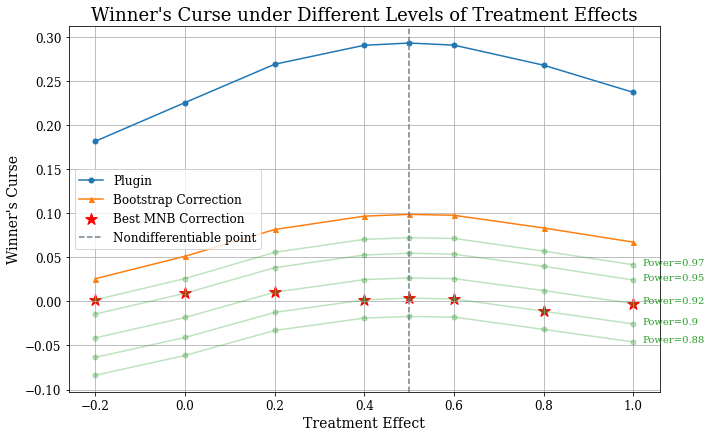

In [61]:
fig, ax = plt.subplots(figsize=(10, 6.18))

# plot plugin estimator
ax.plot(plugin_df['tau'], plugin_df['plugin_mean'], 'o-', markersize=5, label='Plugin', color='C0')

# plot bootstrap estimator
ax.plot(bootstrap_df['tau'], bootstrap_df['stand_bootstrap_mean'], '^-', markersize=5, label='Bootstrap Correction', color='C1')

# plot m out of n bootstrap estimator
for power in power_arr:
    mnb_df = result_df[result_df['power'] == power][['tau', 'mn_bootstrap_mean']]
    ax.plot(mnb_df['tau'], mnb_df['mn_bootstrap_mean'], 'o-', color='C2', alpha=0.3, markersize=5)
    ax.text(
        1.02, mnb_df[mnb_df['tau'] == 1.0]['mn_bootstrap_mean'].values[0], 
        f'Power={power}', 
        fontsize=10, color='C2'
    )

# mark the best hyperparameters for each tau
ax.scatter(tau_arr, best_wc_list, color='red', marker='*', s=150, label='Best MNB Correction')

# plot the nondifferentiable point
ax.axvline(targeting_params['cost'] / targeting_params['price'], color='slategray', linestyle='--', label='Nondifferentiable point')

ax.set_title("Winner's Curse under Different Levels of Treatment Effects", fontsize=title_size)
ax.set_xlabel('Treatment Effect', fontsize=axis_label_size)
ax.set_ylabel("Winner's Curse", fontsize=axis_label_size)
ax.legend(loc='best', fontsize=legend_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()

plt.tight_layout()
plt.savefig('figures/case1-mnb-hyperparam-test.png')
plt.show()

### Numerical bootstrap

In [22]:
targeting_params = {'price': 1, 'cost': 0.5}

dgp_params = {'te': np.nan, 'noise_std': 5, 'treatment_space': np.array([0, 1])}

data_params = {'sample_size': 200}

experiment_params = {'n_experiments': 1000}

estimators_dict = {
    'stand_bootstrap': {
        'estimator': btss.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard'}
    }, 
    'num_bootstrap': {
        'estimator': btss.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'numerical', 
            'power': np.nan
        }
    },
}

In [ ]:
te_list = [-0.2, 0, 0.2, 0.4, 0.5, 0.6, 0.8, 1]
power_list = [-0.35, -0.40, -0.43, -0.45, -0.49]
result_dict = {(te, power): None for te in te_list for power in power_list}

for te in te_list:
    dgp_params['te'] = te
    for power in power_list: 
        print(f'\nTE = {te}, Power = {power}')
        estimators_dict['num_bootstrap']['params']['power'] = power
        
        result_record = btss.repeated_experiments(
            operations_params=operations_params, 
            dgp_params=dgp_params, 
            data_params=data_params, 
            experiment_params=experiment_params, 
            estimators_dict=estimators_dict, 
            verbose=True, n_jobs=-1
        )

        wc_df = pd.DataFrame({
            name: np.array([record[f'{name}_wc'] for record in result_record]) 
            for name in list(estimators_dict.keys()) + ['plugin']
        })

        result_dict[(te, power)] = {
            f'{col}_mean': wc_df[col].mean() for col in wc_df.columns
        }

        result_dict[(te, power)].update({
            f'{col}_se': wc_df[col].std() / np.sqrt(data_params['sample_size'])
            for col in wc_df.columns
        })

with open('results/case1_numb_hyperparam_test.pkl', 'wb') as f:
    pickle.dump(result_dict, f)

In [62]:
with open('results/case1_numb_hyperparam_test.pkl', 'rb') as f:
    result_dict = pickle.load(f)

result_df = pd.DataFrame.from_records([
    {
        'tau': tau, 'power': power, 
        **result_dict[(tau, power)]
    } for tau, power in result_dict.keys()
])

tau_arr = np.unique(result_df['tau'])
power_arr = np.unique(result_df['power'])

plugin_df = result_df[result_df['power'] == power_arr[0]][['tau', 'plugin_mean']]
bootstrap_df = result_df[result_df['power'] == power_arr[0]][['tau', 'stand_bootstrap_mean']]
best_wc_list = [None] * len(tau_arr)
for idx, tau in enumerate(tau_arr):
    temp = result_df[result_df['tau'] == tau][['power', 'num_bootstrap_mean']]
    best_wc_list[idx] = temp['num_bootstrap_mean'].loc[(-temp['num_bootstrap_mean'].abs()).idxmax()]

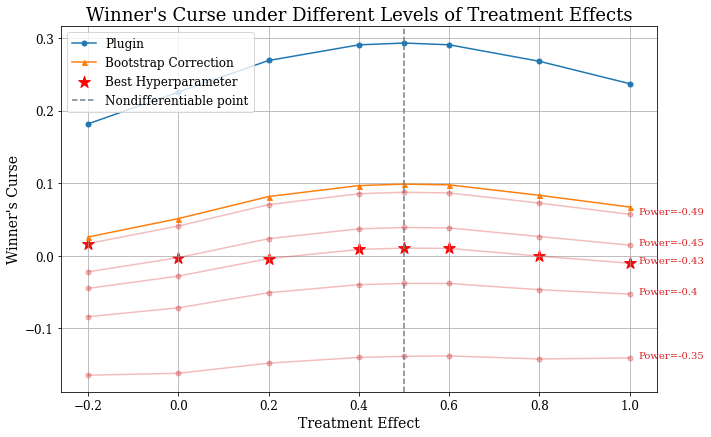

In [63]:
fig, ax = plt.subplots(figsize=(10, 6.18))

# plot plugin estimator
ax.plot(plugin_df['tau'], plugin_df['plugin_mean'], 'o-', markersize=5, label='Plugin', color='C0')

# plot bootstrap estimator
ax.plot(bootstrap_df['tau'], bootstrap_df['stand_bootstrap_mean'], '^-', markersize=5, label='Bootstrap Correction', color='C1')

# plot m out of n bootstrap estimator
for power in power_arr:
    mnb_df = result_df[result_df['power'] == power][['tau', 'num_bootstrap_mean']]
    ax.plot(mnb_df['tau'], mnb_df['num_bootstrap_mean'], 'o-', color='C3', alpha=0.3, markersize=5)
    ax.text(
        1.02, mnb_df[mnb_df['tau'] == 1.0]['num_bootstrap_mean'].values[0], 
        f'Power={power}', 
        fontsize=10, color='C3'
    )

# mark the best hyperparameters for each tau
ax.scatter(tau_arr, best_wc_list, color='red', marker='*', s=150, label='Best Hyperparameter')

# plot the nondifferentiable point
ax.axvline(targeting_params['cost'] / targeting_params['price'], color='slategray', linestyle='--', label='Nondifferentiable point')

ax.set_title("Winner's Curse under Different Levels of Treatment Effects", fontsize=title_size)
ax.set_xlabel('Treatment Effect', fontsize=axis_label_size)
ax.set_ylabel("Winner's Curse", fontsize=axis_label_size)
ax.legend(loc='best', fontsize=legend_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()

plt.tight_layout()
plt.savefig('figures/case1-numb-hyperparam-test.png')
plt.show()

## Sample Size

In [73]:
targeting_params = {'price': 1, 'cost': 0.5}

dgp_params = {'te': 0.6, 'noise_std': 5, 'treatment_space': np.array([0, 1])}

data_params = {'sample_size': np.nan}

experiment_params = {'n_experiments': 10000}

estimators_dict = {
    'stand_bootstrap': {
        'estimator': btss.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard'}
    }, 
    'mn_bootstrap': {
        'estimator': btss.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'm_out_of_n', 
            'power': 0.97
        }
    }, 
    'num_bootstrap': {
        'estimator': btss.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'numerical', 
            'power': - 0.47
        }
    }
}

In [74]:
sample_size_list = [100, 200, 300, 400, 500, 750, 1000, 2000, 3000, 4000, 5000]
result_dict = {sample_size: None for sample_size in sample_size_list}

for idx, sample_size in enumerate(sample_size_list):
    print('\nSample Size:', sample_size)
    data_params['sample_size'] = sample_size

    result_records = btss.repeated_experiments(
        operations_params=operations_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
        verbose=True, n_jobs=-1
    )

    wc_df = pd.DataFrame({
        name: np.array([record[f'{name}_wc'] for record in result_records]) 
        for name in list(estimators_dict.keys()) + ['plugin']
    })

    result_dict[sample_size] = {
        f'{col}_mean': wc_df[col].mean() for col in wc_df.columns
    }

    result_dict[sample_size].update({
        f'{col}_se': wc_df[col].std() / np.sqrt(data_params['sample_size'])
        for col in wc_df.columns
    })

with open('results/case1_sample_size_test.pkl', 'wb') as f:
    pickle.dump(result_dict, f)


Sample Size: 100
Running 10000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-1)]: Done 500 tasks      | elapsed:    4.9s
[Parallel(n_jobs=-1)]: Done 1500 tasks      | elapsed:    9.3s
[Parallel(n_jobs=-1)]: Done 2900 tasks      | elapsed:   15.4s
[Parallel(n_jobs=-1)]: Done 4700 tasks      | elapsed:   23.2s
[Parallel(n_jobs=-1)]: Done 6900 tasks      | elapsed:   33.0s
[Parallel(n_jobs=-1)]: Done 9500 tasks      | elapsed:   44.5s
[Parallel(n_jobs=-1)]: Done 10000 out of 10000 | elapsed:   46.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Sample Size: 200
Running 10000 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 620 tasks      | elapsed:    3.0s
[Parallel(n_jobs=-1)]: Done 1620 tasks      | elapsed:    7.5s
[Parallel(n_jobs=-1)]: Done 3020 tasks      | elapsed:   13.9s
[Parallel(n_jobs=-1)]: Done 4820 tasks      | elapsed:   22.2s
[Parallel(n_jobs=-1)]: Done 7020 tasks      | elapsed:   32.4s
[Parallel(n_jobs=-1)]: Done 9620 tasks      | elapsed:   44.4s
[Parallel(n_jobs=-1)]: Done 9981 out of 10000 | elapsed:   46.1s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done 10000 out of 10000 | elapsed:   46.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Sample Size: 300
Running 10000 experiments...


...

[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    4.0s
[Parallel(n_jobs=-1)]: Done 840 tasks      | elapsed:    9.5s
[Parallel(n_jobs=-1)]: Done 1540 tasks      | elapsed:   16.9s
[Parallel(n_jobs=-1)]: Done 2440 tasks      | elapsed:   26.6s
[Parallel(n_jobs=-1)]: Done 3540 tasks      | elapsed:   38.7s
[Parallel(n_jobs=-1)]: Done 4840 tasks      | elapsed:   54.0s
[Parallel(n_jobs=-1)]: Done 6340 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 8040 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done 9940 tasks      | elapsed:  1.9min
[Parallel(n_jobs=-1)]: Done 10000 out of 10000 | elapsed:  1.9min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Sample Size: 4000
Running 10000 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    3.9s
[Parallel(n_jobs=-1)]: Done 840 tasks      | elapsed:   10.0s
[Parallel(n_jobs=-1)]: Done 1540 tasks      | elapsed:   18.3s
[Parallel(n_jobs=-1)]: Done 2440 tasks      | elapsed:   28.0s
[Parallel(n_jobs=-1)]: Done 3540 tasks      | elapsed:   41.0s
[Parallel(n_jobs=-1)]: Done 4840 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 6340 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done 8040 tasks      | elapsed:  1.9min
[Parallel(n_jobs=-1)]: Done 9940 tasks      | elapsed:  2.3min
[Parallel(n_jobs=-1)]: Done 10000 out of 10000 | elapsed:  2.3min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Sample Size: 5000
Running 10000 experiments...


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:    3.3s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:    7.9s
[Parallel(n_jobs=-1)]: Done 780 tasks      | elapsed:   14.4s
[Parallel(n_jobs=-1)]: Done 1230 tasks      | elapsed:   22.5s
[Parallel(n_jobs=-1)]: Done 1780 tasks      | elapsed:   32.5s
[Parallel(n_jobs=-1)]: Done 2430 tasks      | elapsed:   44.3s
[Parallel(n_jobs=-1)]: Done 3180 tasks      | elapsed:   59.5s
[Parallel(n_jobs=-1)]: Done 4030 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done 4980 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done 6030 tasks      | elapsed:  1.9min
[Parallel(n_jobs=-1)]: Done 7180 tasks      | elapsed:  2.3min
[Parallel(n_jobs=-1)]: Done 8430 tasks      | elapsed:  2.7min
[Parallel(n_jobs=-1)]: Done 9780 tasks      | elapsed:  3.1min
[Parallel(n_jobs=-1)]: Done 10000 out of 10000 | elapsed:  3.2min finished


In [75]:
with open('results/case1_sample_size_test.pkl', 'rb') as f:
    result_dict = pickle.load(f)

result_df = pd.DataFrame.from_dict(result_dict).T

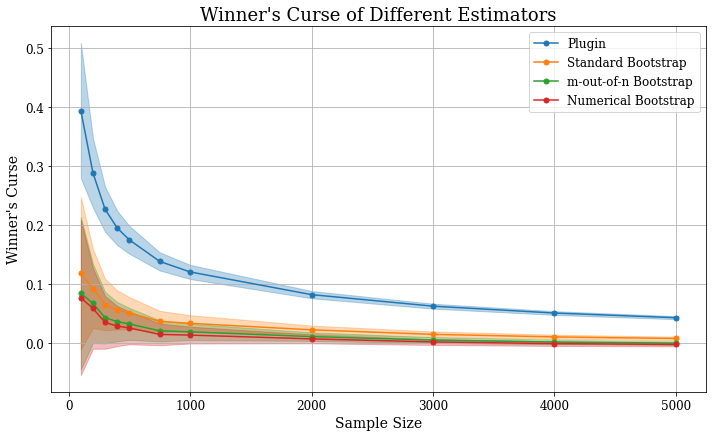

In [76]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# plugin estimator
ax.plot(result_df.index, result_df['plugin_mean'], 'o-', markersize=5, label='Plugin', color='C0')
ax.fill_between(
    result_df.index, 
    result_df['plugin_mean'] - 1.96 * result_df['plugin_se'], 
    result_df['plugin_mean'] + 1.96 * result_df['plugin_se'], 
    color='C0', alpha=0.3
)
# ax.errorbar(
#     x=result_df.index, y=result_df['plugin_mean'], yerr= 1.96 * result_df['plugin_se'], 
#     fmt='o', capsize=5, label='Plugin', color='C0'
# )

# standard bootstrap 
ax.plot(result_df.index, result_df['stand_bootstrap_mean'], 'o-', markersize=5, label='Standard Bootstrap', color='C1')
ax.fill_between(
    result_df.index, 
    result_df['stand_bootstrap_mean'] - 1.96 * result_df['stand_bootstrap_se'], 
    result_df['stand_bootstrap_mean'] + 1.96 * result_df['stand_bootstrap_se'], 
    color='C1', alpha=0.3
)

# m out of n bootstrap
ax.plot(result_df.index, result_df['mn_bootstrap_mean'], 'o-', markersize=5, label='m-out-of-n Bootstrap', color='C2')
ax.fill_between(
    result_df.index, 
    result_df['mn_bootstrap_mean'] - 1.96 * result_df['mn_bootstrap_se'], 
    result_df['mn_bootstrap_mean'] + 1.96 * result_df['mn_bootstrap_se'], 
    color='C2', alpha=0.3
)

# numerical bootstrap
ax.plot(result_df.index, result_df['num_bootstrap_mean'], 'o-', markersize=5, label='Numerical Bootstrap', color='C3')
ax.fill_between(
    result_df.index, 
    result_df['num_bootstrap_mean'] - 1.96 * result_df['num_bootstrap_se'], 
    result_df['num_bootstrap_mean'] + 1.96 * result_df['num_bootstrap_se'], 
    color='C3', alpha=0.3
)

ax.set_title("Winner's Curse of Different Estimators", fontsize=title_size)
ax.set_xlabel('Sample Size', fontsize=axis_label_size)
ax.set_ylabel("Winner's Curse", fontsize=axis_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()
ax.legend(loc='best', fontsize=legend_label_size)

plt.tight_layout()
plt.savefig('figures/case1-sample-size-test.png')
plt.show()